In [1]:
import numpy
import sys
import os
import matplotlib.pyplot as plt
# import skimage
import nrrd
from scipy import ndimage
import meshio
from skimage.morphology import skeletonize
from scipy.interpolate import splprep, splev
from sklearn.decomposition import PCA
from scipy.spatial import cKDTree
from scipy.interpolate import UnivariateSpline
import trimesh

sys.path.insert(0, "../src")  # add Folder_2 path to search list

from meshing_functions import getSurfaceMesh, tetra_mesh_from_stl, tetra_shell_from_two_surfaces, set_the_offset, export_centerline


pixel_spacing = numpy.loadtxt("/Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/pixel_spacing.txt")

base = "/Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/"

# offset = numpy.loadtxt("/Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/meshes/offset.txt")


in_folder = "segment_final/"    
out_folder = "spline_experiment/"

folder = "Fourier-spline_meshes/"

if not os.path.isdir(base + folder):
    os.mkdir(base + folder)


## Load segments, pixel spacing etc

In [2]:

filename = "Segmentation_1.seg.nrrd"
export_name = base + folder + filename[:-8]

eyeball_id = 1
muslce_ids = [2,3,4,5]
pairs = [(0,2), (1,3)]

lense_id = 7

background_id = -1


data, header = nrrd.read(base + in_folder + filename)
print(data.shape)



id_max = numpy.max(data)

print("pixel spacing = ",pixel_spacing)
print("id = ", id_max )

print("dimensions = ", data.shape)

if pixel_spacing[2]!= pixel_spacing[1]:
    print("resampling")
    factor = pixel_spacing[2]/pixel_spacing[1]
    data = ndimage.zoom(data, [1,1,factor], order = 0)


print("dimensions = ", data.shape)

id = int(numpy.max(data))
print("id = ", id)




(110, 150, 155)
pixel spacing =  [0.5 0.5 0.5]
id =  7
dimensions =  (110, 150, 155)
dimensions =  (110, 150, 155)
id =  7


## Create initial meshes

In [3]:
muscles = []

for id in range(1,numpy.max(data)+1):
    if id != background_id:
    # for id in range(3,4):
        print("id = ", id)


        if len(numpy.where((data>id-0.5) & (data<id+0.5 ))[0])>0:

            mask = numpy.zeros(data.shape, dtype=numpy.uint8)
            mask[(data>id-0.5) & (data<id+0.5 )]=1

            print(len(numpy.where(mask==1)[0]))


            numpy.save(export_name +"_filtered_surf_id_"+str(id), mask)

            if id ==eyeball_id:

                mask = ndimage.median_filter(mask, size=1)
                mask[mask<0.5]=0
                mask[mask>=0.5]=1

                mesh_surf = getSurfaceMesh(mask, export_name +"_surf_id_"+str(id)+".stl", pixel_spacing[0], True )

                mask_voxels = numpy.argwhere(mask == 1)  # shape (N, 3), coordinates in (z, y, x)
                # compute mean voxel position
                offset = mask_voxels.mean(axis=0)*pixel_spacing[0]  # [z_mean, y_mean, x_mean]
                numpy.savetxt(base + folder + "offset.txt", offset)

                mask_eye = mask

            if id in muslce_ids:
                print("Muscle")

                muscles.append(mask)
                mesh_surf = getSurfaceMesh(mask, export_name +"_surf_id_"+str(id)+".stl", pixel_spacing[0], False )

            if id == lense_id:
                mask = ndimage.median_filter(mask, size=1)
                mask[mask<0.5]=0
                mask[mask>=0.5]=1

                mesh_surf = getSurfaceMesh(mask, export_name +"_surf_id_"+str(id)+".stl", pixel_spacing[0], False )


id =  1
65767
Problem edges: 0
Outer and inner surfaces written.
id =  2
8436
Muscle
Problem edges: 4
written file:  /Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/Fourier-spline_meshes/Segmentation_1._surf_id_2.stl
id =  3
4587
Muscle
Problem edges: 0
written file:  /Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/Fourier-spline_meshes/Segmentation_1._surf_id_3.stl
id =  4
7222
Muscle
Problem edges: 1
written file:  /Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/Fourier-spline_meshes/Segmentation_1._surf_id_4.stl
id =  5
6801
Muscle
Problem edges: 6
written file:  /Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/Fourier-spline_meshes/Segmentation_1._surf_id_5.stl
id =  6
6465
id =  7
1372
Problem edges: 4
written file:  /Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/Fourier-spline_meshes/Segmentation_1

## Lense axis

In [4]:
mesh = trimesh.load(export_name +"_surf_id_"+str(lense_id)+".stl")
# mesh.vertices = (mesh.vertices + offset) / pixel_spacing

lense_center = mesh.vertices.mean(axis=0)

print("lense_center = ", lense_center)

X = mesh.vertices - lense_center

_, _, vh = numpy.linalg.svd(X)

axis_direction = vh[-1]  # first principal axis


def axis(t):
    return lense_center + t * axis_direction


axis_points = [axis(-20.0), axis(20.0)]

export_centerline(axis_points, 1.0 , base + folder + "lense_axis.vtp", [0,0,0])

# # # # # # # # # # # # # # # # # # # # # # # # # # # # # 

target_point =  axis(-2.25)/pixel_spacing[0]

print("target_point = ", target_point)

lense_center =  [34.74798285 63.83954948 24.45071852]
target_point =  [ 69.28843289 123.27184881  49.78635298]


## Section curve

- eyeball mesh ∩ place perpendicular to lense axis
- output: section curve

In [5]:
eyeball_mesh = trimesh.load(export_name +"_surf_id_"+str(eyeball_id)+"_outer.stl")

section = eyeball_mesh.section(
    plane_origin=target_point*pixel_spacing[0],
    plane_normal=axis_direction
)

section_curve = []

for entity in section.entities:
    idx = entity.points  # ordered indices
    
    for i in range(len(idx) - 1):
        section_curve.append([idx[i], idx[i+1]])

meshio.write(
    base + folder + "section_curve_A.vtk",
    meshio.Mesh(
        points=section.vertices,
        cells=[("line", numpy.array(section_curve))]
    )
)

## Section curve B & radial expansion


In [6]:
target_point_B =  axis(-10)/pixel_spacing[0]

section_B = eyeball_mesh.section(
    plane_origin=target_point_B*pixel_spacing[0],
    plane_normal=axis_direction
)

section_curve_B = []

for entity in section_B.entities:
    idx = entity.points  # ordered indices
    
    for i in range(len(idx) - 1):
        section_curve_B.append([idx[i], idx[i+1]])


# Center point in physical space 
center_physical = target_point_B * pixel_spacing[0]

original_vertices = numpy.array(section_B.vertices)

# Radial vectors from the center 
radial_vectors = original_vertices - center_physical

magnitudes = numpy.linalg.norm(radial_vectors, axis=1, keepdims=True)
normalized_vectors = radial_vectors / (magnitudes + 1e-8)



# Expand outward by xx mm 
expansion_distance = 2.1  
expanded_vertices = original_vertices + (normalized_vectors * expansion_distance)

section_B.vertices = expanded_vertices

# 6. Rebuild the section_curve line segments using the new expanded coordinates
expanded_section_curve = []
for entity in section_B.entities:
    idx = entity.points  # ordered indices within this specific entity
    
    for i in range(len(idx) - 1):
        # We map the local entity indices directly to our expanded_vertices array
        expanded_section_curve.append([idx[i], idx[i+1]])

meshio.write(
    base + folder + "section_curve_B.vtk",
    meshio.Mesh(
        points=section_B.vertices,
        cells=[("line", numpy.array(expanded_section_curve))]
    )
)

## Functions: 
### Fit centerlines with/without additional constraints

In [7]:
def fit_target_constrained_spline(binned_centers, target_point, smoothing_factor=1.5):
    """
    binned_centers: (N, 3) array of centers from the mask
    target_point: (3,) array [z, y, x] where the object should end
    """
    # 1. Append the target point to the end of your centers
    # We ensure target_point is shaped correctly for concatenation
    target_point = numpy.array(target_point).reshape(1, 3)
    constrained_points = numpy.concatenate([binned_centers, target_point], axis=0)
    
    # 2. Assign Weights (w)
    # We give the target point a very high weight (e.g., 10) 
    # and the noisy data points a lower weight (e.g., 1)
    weights = numpy.ones(len(constrained_points))
    weights[-1] = 20.0  # Force the spline to prioritize hitting the target
    
    # 3. Fit the Spline
    # We use the transpose .T because splprep expects (3, N)
    try:
        # Note: 'w' is the weights, 's' is the overall smoothing
        tck, u = splprep(constrained_points.T, w=weights, s=smoothing_factor, k=3)
        
        # 4. Evaluate from 0 to 1
        # Since the target is now the last point in the data, 
        # u=1.0 will correspond to the target point.
        u_new = numpy.linspace(-0.05, 1.0, 160)
        smooth_centerline = numpy.array(splev(u_new, tck)).T
        
        return smooth_centerline
    except Exception as e:
        print(f"Constrained spline fit failed: {e}")
        return None
    
def fit_3_constrained_spline(binned_centers, target_1, target_2, target_3, smoothing_factor=1.5):
    """
    Fits a spline through binned centers and 3 target guiding points,
    """
    # 1. Combine all points into one unordered pool
    target_1 = numpy.array(target_1).reshape(1, 3)
    target_2 = numpy.array(target_2).reshape(1, 3)
    target_3 = numpy.array(target_3).reshape(1, 3)
    
    unordered_points = numpy.concatenate([binned_centers, target_1], axis=0)
    
    # 2. Use PCA  to find the true main orientation axis
    pca = PCA(n_components=1)
    projection = pca.fit_transform(unordered_points)
    
    # 3. Sort ALL points based on their position along this principal axis
    sort_idx = numpy.argsort(projection.flatten())
    constrained_points = unordered_points[sort_idx]

    constrained_points = numpy.concatenate([constrained_points, target_2, target_3], axis=0)
    
    # 4. Flip check (Ensure Target 3 is at the end)
    distances_to_end = numpy.linalg.norm(constrained_points - target_3, axis=1)
    if numpy.argmin(distances_to_end) == 0:
        constrained_points = numpy.flip(constrained_points, axis=0)

    # 5. Assign Weights dynamically by finding where the targets landed
    weights = numpy.ones(len(constrained_points))
    
    for target in [target_1]:
        distances = numpy.linalg.norm(constrained_points - target, axis=1)
        matched_idx = numpy.argmin(distances)
        weights[matched_idx] = 50
    
    weights[0] = 20
    weights[-1] = 20

    # 6. Fit the Spline
    try:
        tck, u = splprep(constrained_points.T, w=weights, s=smoothing_factor, k=3)
        
        # Evaluate slightly past the boundaries to allow mathematical extension
        u_new = numpy.linspace(-0.05, 1.0, 160)
        smooth_centerline = numpy.array(splev(u_new, tck)).T
        
        return smooth_centerline
    
    except Exception as e:
        print(f"PCA-Ordered 3-point constrained spline fit failed: {e}")
        return None
    

def fit_dual_constrained_spline(binned_centers, target_1, target_2, smoothing_factor=1.5):
    """
    binned_centers: (N, 3) array of centers from the mask
    target_1: (3,) array where the object should begin
    target_2: (3,) array where the object should end
    """
    # 1. Prepare the sequence: [Start, Binned Data, End]
    points = [
        binned_centers,
        numpy.array(target_1).reshape(1, 3),
        numpy.array(target_2).reshape(1, 3)
    ]
    constrained_points = numpy.concatenate(points, axis=0)
    
    # 2. Assign Weights
    # Weights[0] is Start, Weights[-1] is End. 
    # High values force the spline to hit those exact coordinates.
    weights = numpy.ones(len(constrained_points))
    weights[0] = 50.0  # Force start
    weights[-1] = 50.0 # Force end
    
    # 3. Fit the Spline
    # We pass the weights array to 'w'
    try:
        tck, u = splprep(constrained_points.T, w=weights, s=smoothing_factor, k=3)
        
        # 4. Evaluate
        # u=0.0 will be target_start, u=1.0 will be target_end
        u_new = numpy.linspace(-0.05, 1.0, 160)
        smooth_centerline = numpy.array(splev(u_new, tck)).T
        
        return smooth_centerline
    except Exception as e:
        print(f"Dual constrained spline fit failed: {e}")
        return None

def fit_analytical_centerline(mask, target_point, ignored_nodes, n_bins=20, extension_factor=0.2):
        # 1. Get all voxel coordinates (Z, Y, X)
        points = numpy.argwhere(mask == 1).astype(float)
        
        if len(points) < 10:
            return None

        # 2. Find the main orientation using PCA
        pca = PCA(n_components=1)
        # Project points onto the first principal component 
        projection = pca.fit_transform(points)
        
        # 3. Sort points based on their position along the principal axis
        sort_idx = numpy.argsort(projection.flatten())

        sort_idx = sort_idx[int(len(sort_idx)*ignored_nodes):int(len(sort_idx)*(1-ignored_nodes))]

        sorted_points = points[sort_idx]
        sorted_projection = projection[sort_idx].flatten()

        # 4. Create "Binned Centers" to handle the noise
        # Fit to the average center of 'n' slices
        bins = numpy.linspace(sorted_projection.min(), sorted_projection.max(), n_bins)
        binned_centers = []
        
        for i in range(len(bins)-1):
            # Find points that fall within this slice of the object
            mask_slice = (sorted_projection >= bins[i]) & (sorted_projection < bins[i+1])
            if numpy.any(mask_slice):
                center = sorted_points[mask_slice].mean(axis=0)
                binned_centers.append(center)
        
        binned_centers = numpy.array(binned_centers)

        # # 5. Fit the Spline to the centers
        # # Smoothing 's' can be lower here because the binning already cleaned the noise
        tck, u = splprep(binned_centers.T, s=3.5, k=2)
        
        # # 6. Extend the object
        # # Evaluating from 0.0 to 1+extension extends the centerline
        smooth_centerline = numpy.array(splev(numpy.linspace(-extension_factor, 1.0, 100), tck)).T

        if len(target_point)==0:
            return smooth_centerline
        
        if len(target_point)==1:
            smooth_centerline_extended = fit_target_constrained_spline(binned_centers, target_point[0])
            return smooth_centerline, smooth_centerline_extended
        
        if len(target_point)==2:
            smooth_centerline_extended = fit_dual_constrained_spline(binned_centers, target_point[0], target_point[1] )
            return smooth_centerline, smooth_centerline_extended

        if len(target_point)==3:
            smooth_centerline_extended = fit_3_constrained_spline(binned_centers, target_point[0], target_point[1], target_point[2] )
            return smooth_centerline, smooth_centerline_extended    


## Functions:
### Get insertion points ~ section curve / fitted planes

In [8]:
def fit_plane_to_two_centerlines(centerline1, centerline2):
    # 1. Combine all points from both centerlines into one cloud
    points = numpy.vstack((centerline1, centerline2))
    
    # 2. Calculate the centroid (the average point)
    centroid = numpy.mean(points, axis=0)
    
    # 3. Center the points by subtracting the centroid
    centered_points = points - centroid
    
    # 4. Use Singular Value Decomposition
    _, _, vh = numpy.linalg.svd(centered_points)
    
    # 5. The normal vector 'n' is the last row of Vh 
    # (the direction with the least variance/spread)
    normal = vh[-1]
    
    return centroid, normal/numpy.linalg.norm(normal)

def find_plane_curve_intersections(section, section_curve, plane_centroid, plane_normal):
    intersections = []
    
    # Normalize plane normal just in case
    plane_normal = plane_normal / numpy.linalg.norm(plane_normal)
    
    vertices = section.vertices
    
    for start_idx, end_idx in section_curve:
        p1 = vertices[start_idx]
        p2 = vertices[end_idx]
        
        # Signed distances to the plane
        d1 = numpy.dot(p1 - plane_centroid, plane_normal)
        d2 = numpy.dot(p2 - plane_centroid, plane_normal)
        
        # Check if the segment crosses the plane
        if d1 * d2 < 0:
            # Linear interpolation to find the exact crossing point
            t = abs(d1) / (abs(d1) + abs(d2))
            intersect_pt = p1 + t * (p2 - p1)
            intersections.append(intersect_pt)
            
    return numpy.array(intersections)



In [9]:
extended_centerlines = []
centerlines = []
extended_centerlines_1 = []

# target_point = point on the lense axis

for muscle_id in range(len(muslce_ids)):
    mask = muscles[muscle_id]
    ignored_nodes = 0.01

    centerline, centerline_ext_1 = fit_analytical_centerline(mask, [target_point], ignored_nodes, n_bins=10, extension_factor=0.15)
    
    centerlines.append(centerline)
    extended_centerlines.append(centerline_ext_1)


    export_centerline(centerline_ext_1, pixel_spacing[0], base + folder + "centerline_exttended_1_id_"+str(muslce_ids[muscle_id])+".vtp", [0,0,0])
    export_centerline(centerline, pixel_spacing[0], base + folder + "centerline_init_id_"+str(muslce_ids[muscle_id])+".vtp", [0,0,0])


point_hor, normal_vector_hor = fit_plane_to_two_centerlines(extended_centerlines[pairs[0][0]], extended_centerlines[pairs[0][1]])
point_vert, normal_vector_vert = fit_plane_to_two_centerlines(extended_centerlines[pairs[1][0]], extended_centerlines[pairs[1][1]])

print("Check of angle  = ", numpy.dot(normal_vector_hor, normal_vector_vert))

# Plane 1 intersections
pts_plane1 = find_plane_curve_intersections(section, section_curve, point_hor*pixel_spacing[0], normal_vector_hor)
# Plane 2 intersections
pts_plane2 = find_plane_curve_intersections(section, section_curve, point_vert*pixel_spacing[0], normal_vector_vert)


# Plane 1B intersections
pts_plane1_B = find_plane_curve_intersections(section_B, section_curve_B, point_hor*pixel_spacing[0], normal_vector_hor)
# Plane 2B intersections
pts_plane2_B = find_plane_curve_intersections(section_B, section_curve_B, point_vert*pixel_spacing[0], normal_vector_vert)

for muscle_id in range(len(muslce_ids)):

    if muscle_id == pairs[0][0]:
        target_1 = pts_plane1[1]/pixel_spacing[0]
        target_1_B = pts_plane1_B[1]/pixel_spacing[0]

    elif muscle_id == pairs[0][1]:
        target_1 = pts_plane1[0]/pixel_spacing[0]
        target_1_B = pts_plane1_B[0]/pixel_spacing[0]

    if muscle_id == pairs[1][1]:
        target_1 = pts_plane2[0]/pixel_spacing[0]
        target_1_B = pts_plane2_B[0]/pixel_spacing[0]

    elif muscle_id == pairs[1][0]:
        target_1 = pts_plane2[1]/pixel_spacing[0]
        target_1_B = pts_plane2_B[1]/pixel_spacing[0]

    mask = muscles[muscle_id]

    _, centerline_ext_2 = fit_analytical_centerline(mask, [target_1_B, target_1, target_point], ignored_nodes, n_bins=10, extension_factor=0.25)

    extended_centerlines_1.append(centerline_ext_2)


    export_centerline(centerline_ext_2, pixel_spacing[0], base + folder + "centerline_exttended_2_id_"+str(muslce_ids[muscle_id])+".vtp", [0,0,0])



Check of angle  =  0.05153277060902848


## Find intersection of the extended centerline and the eyeball


In [10]:
def find_eye_intersection_index(centerline_extended, mask_eye):
    """
    Returns the index along the extended centerline that intersects the eye.
    """
    for idx, point in enumerate(centerline_extended):
        z, y, x = numpy.round(point).astype(int)
        
        # Check bounds
        if 0 <= z < mask_eye.shape[0] and 0 <= y < mask_eye.shape[1] and 0 <= x < mask_eye.shape[2]:
            if mask_eye[z, y, x] == 1:
                return idx  
                
    return len(centerline_extended) - 1


# Part II

In [11]:
def get_local_frame(direction):
    """Calculates two vectors perpendicular to the spine direction."""
    # Pick a non-parallel vector to start the cross product
    vec = numpy.array([1, 0, 0]) if abs(direction[0]) < 0.9 else numpy.array([0, 1, 0])
    v1 = numpy.cross(direction, vec)
    v1 /= numpy.linalg.norm(v1)
    v2 = numpy.cross(direction, v1)
    return v1, v2



# def fit_fourier_contour(theta, r, K=3):
#     """
#     Fit

#     r(θ)=a0 + Σ ak cos(kθ)+bk sin(kθ)

#     Returns coefficient vector:
#     [a0,a1,b1,a2,b2,...]
#     """

#     M = [numpy.ones_like(theta)]

#     for k in range(1, K + 1):
#         M.append(numpy.cos(k * theta))
#         M.append(numpy.sin(k * theta))

#     M = numpy.column_stack(M)

#     coeffs, *_ = numpy.linalg.lstsq(M, r, rcond=None)

#     # ---- NEW: damp higher frequencies ----
#     for k in range(2, K + 1):
#         idx = 2 * (k - 1) + 1
#         coeffs[idx] *= 0.3
#         coeffs[idx + 1] *= 0.3

#     return coeffs

def fit_fourier_contour(theta, r, K=3, lam=1e-2, weights=None):
    """
    Stable Fourier fit:

    r(θ) = a0 + Σ ak cos(kθ) + bk sin(kθ)

    Returns:
    [a0, a1, b1, a2, b2, ...]
    """

    # -----------------------------
    # 1. normalize angle to avoid asymmetry
    # -----------------------------
    theta = (theta + numpy.pi) % (2 * numpy.pi) - numpy.pi

    # -----------------------------
    # 2. build Fourier design matrix
    # -----------------------------
    M = [numpy.ones_like(theta)]

    for k in range(1, K + 1):
        M.append(numpy.cos(k * theta))
        M.append(numpy.sin(k * theta))

    M = numpy.column_stack(M)

    # -----------------------------
    # 3. optional weighting (VERY useful for point clouds)
    # -----------------------------
    if weights is None:
        weights = numpy.ones_like(theta)

    w = numpy.sqrt(weights)

    M_w = M * w[:, None]
    r_w = r * w

    # -----------------------------
    # 4. ridge-regularized least squares
    # -----------------------------
    A = M_w.T @ M_w + lam * numpy.eye(M.shape[1])
    b = M_w.T @ r_w

    coeffs = numpy.linalg.solve(A, b)


    return coeffs




def extract_fourier_profiles(
        centerline,
        init_mesh_surf,
        pixel_spacing,
        K=3):

    mesh_points = numpy.array(
        init_mesh_surf.vertices / pixel_spacing[0]
    )

    tree = cKDTree(mesh_points)

    coeffs_all = []

    for i,p in enumerate(centerline):

        direction = (
            centerline[min(i+1,len(centerline)-1)]
            - centerline[max(i-1,0)]
        )

        direction /= numpy.linalg.norm(direction)

        v1,v2 = get_local_frame(direction)

        idx = tree.query_ball_point(p,r=45)

        local_pts = mesh_points[idx] - p

        dist_plane = numpy.dot(local_pts,direction)

        slab = numpy.abs(dist_plane) < 5

        local_pts = local_pts[slab]

        if len(local_pts) < 20:
            coeffs_all.append(None)
            continue

        x = local_pts @ v1
        y = local_pts @ v2

        theta = numpy.arctan2(y,x)
        r = numpy.sqrt(x*x+y*y)

        coeffs = fit_fourier_contour(theta,r,K)

        coeffs_all.append(coeffs)

    return coeffs_all

def smooth_fourier_coefficients(
        coeffs_all,
        n_output,
        smoothing=1):

    coeffs_all = numpy.asarray(coeffs_all)

    n_input,n_coeff = coeffs_all.shape

    s_in = numpy.linspace(0,1,n_input)
    s_out = numpy.linspace(0,1,n_output)

    coeffs_smooth = numpy.zeros(
        (n_output,n_coeff)
    )

    for j in range(n_coeff):

        spl = UnivariateSpline(
            s_in,
            coeffs_all[:,j],
            k=3,
            s=smoothing
        )

        coeffs_smooth[:,j] = spl(s_out)

    return coeffs_smooth

def smooth_fourier_coefficients_alt(coeffs_all, n_output, smoothing=1):
    coeffs_all = numpy.asarray(coeffs_all)
    n_input, n_coeff = coeffs_all.shape

    nodes_out = numpy.arange(n_output)
    coeffs_smooth = numpy.zeros((n_output, n_coeff))

    for j in range(n_coeff):
        valid_indices = numpy.where(~numpy.isnan(coeffs_all[:, j]))[0]
        
        if len(valid_indices) == 0:
            continue
            
        last_valid_idx = valid_indices[-1]
        last_valid_value = coeffs_all[last_valid_idx, j]

        # --- FIX 1: LOWER SPLINE DEGREE TO PREVENT EXPLOSIONS ---
        # Using k=2 (quadratic) or k=1 (linear) for the spline fit 
        # prevents the aggressive polynomial "whip" of a cubic (k=3) spline.
        k_order = 2 if len(valid_indices) > 2 else 1

        spl = UnivariateSpline(
            valid_indices,
            coeffs_all[valid_indices, j],
            k=k_order,
            s=smoothing
        )

        # Evaluate the trend
        extrapolated_profile = spl(nodes_out)

        # --- FIX 2: ANATOMICAL GUARDRAILS FOR EXTRAPOLATION ZONE ---
        # Identify which output nodes belong to the unsegmented extension zone
        ext_mask = nodes_out > last_valid_idx
        
        if numpy.any(ext_mask):
            if j == 0:
                # j=0 is the mean radius (size) of the muscle cross-section.
                # We strictly forbid it from exploding. It must either stay flat 
                # or gracefully taper down toward a tendon size.
                
                # Option A: Clamp it so it can NEVER exceed the last known mask radius
                max_allowed_radius = last_valid_value
                
                # Option B (Anatomical): Force it to linearly taper down to a reasonable 
                # tendon thickness (e.g., 1.0mm) at the insertion point
                taper_radius = 1.0 / pixel_spacing[0] 
                
                ext_nodes = nodes_out[ext_mask]
                # Create a linear blend from the last known value to the tendon target
                t = (ext_nodes - last_valid_idx) / (n_output - 1 - last_valid_idx)
                # Clip t to max out at 1.0 just in case
                t = numpy.clip(t, 0, 1) 
                
                extrapolated_profile[ext_mask] = (1 - t) * last_valid_value + t * taper_radius
                
            else:
                # j > 0 are the shape harmonics (the ovalness/deformations).
                # As the muscle becomes a tendon, it should lose its complex shape and become round.
                # We fade higher harmonics down to 0.
                ext_nodes = nodes_out[ext_mask]
                t = (ext_nodes - last_valid_idx) / (n_output - 1 - last_valid_idx)
                t = numpy.clip(t, 0, 1)
                
                extrapolated_profile[ext_mask] = extrapolated_profile[ext_mask] * (1.0 - t)

        coeffs_smooth[:, j] = extrapolated_profile

    return coeffs_smooth

def evaluate_fourier_contour(coeffs,theta):

    r = coeffs[0]

    idx = 1

    K = (len(coeffs)-1)//2

    for k in range(1,K+1):

        ak = coeffs[idx]
        bk = coeffs[idx+1]

        r += ak*numpy.cos(k*theta)
        r += bk*numpy.sin(k*theta)

        idx += 2

    return r

## Generate mesh directly

In [12]:
def generate_fourier_mesh(
        centerline,
        coeffs_smooth,
        pixel_spacing,
        n_theta=48,
        insertion_idx=None,
        taper_start_len=12,
        taper_end_len=12):
    """
    Fourier muscle mesh with:
    - smooth proximal taper (origin)
    - smooth distal taper (insertion)
    - no hard caps
    """

    n_sections = len(centerline)

    if insertion_idx is None:
        insertion_idx = n_sections

    n_sections = min(n_sections, insertion_idx)

    vertices = []

    theta = numpy.linspace(0, 2*numpy.pi, n_theta, endpoint=False)

    # endpoint for both collapses
    start_point = centerline[0]
    end_point = centerline[n_sections - 1]

    for i in range(n_sections):

        # ---------------------------------
        # local frame
        # ---------------------------------
        direction = (
            centerline[min(i+1, n_sections-1)]
            - centerline[max(i-1, 0)]
        )
        direction /= (numpy.linalg.norm(direction) + 1e-8)

        v1, v2 = get_local_frame(direction)

        # Fourier radius
        r = evaluate_fourier_contour(coeffs_smooth[i], theta)
        r = numpy.maximum(r, 0.05)


        P = centerline[i]

        # =========================================================
        # PROXIMAL TAPER (START)
        # =========================================================
        if i < taper_start_len:
            t = i / max(taper_start_len - 1, 1)   # 0 → 1

            # smoother biological opening
            scale = t**2

            P = (1 - t) * start_point + t * P
            r = r * scale

        # =========================================================
        # DISTAL TAPER (END)
        # =========================================================
        if i >= n_sections - taper_end_len:
            t = (i - (n_sections - taper_end_len)) / max(taper_end_len - 1, 1)

            scale = (1 - t)**2

            P = (1 - t) * P + t * end_point
            r = r * scale

        # ---------------------------------
        # ring construction
        # ---------------------------------
        ring = (
            P[None, :]
            + r[:, None] * numpy.cos(theta)[:, None] * v1[None, :]
            + r[:, None] * numpy.sin(theta)[:, None] * v2[None, :]
        )

        vertices.append(ring)

    vertices = numpy.vstack(vertices)

    # ---------------------------------
    # connectivity
    # ---------------------------------
    faces = []

    for i in range(n_sections - 1):

        base0 = i * n_theta
        base1 = (i + 1) * n_theta

        for j in range(n_theta):

            j2 = (j + 1) % n_theta

            v00 = base0 + j
            v01 = base0 + j2
            v10 = base1 + j
            v11 = base1 + j2

            faces.append([v00, v10, v11])
            faces.append([v00, v11, v01])

    mesh = trimesh.Trimesh(
        vertices=vertices * pixel_spacing,
        faces=numpy.asarray(faces),
        process=False
    )

    return mesh

## Mesh generating loop

In [13]:
for muscle_id in range(len(muslce_ids)):

    

    print("Processing muscle", muslce_ids[muscle_id])

    init_mesh = trimesh.load(export_name +"_surf_id_" + str(muslce_ids[muscle_id]) +".stl")

    coeffs_all = extract_fourier_profiles(centerlines[muscle_id], init_mesh, pixel_spacing, K=4)

    coeffs_all = numpy.asarray(coeffs_all)


    # fill NaNs
    for j in range(coeffs_all.shape[1]):

        valid = ~numpy.isnan(coeffs_all[:,j])

        coeffs_all[:,j] = numpy.interp(numpy.arange(len(valid)), numpy.where(valid)[0],coeffs_all[valid,j])

    # Insertion point

    intersection_idx = find_eye_intersection_index(
    extended_centerlines_1[muscle_id],
    mask_eye
    )

    coeffs_smooth = smooth_fourier_coefficients(
    coeffs_all,
    n_output=intersection_idx+1,
    smoothing=0.02
    )
    
    centerline_trimmed = extended_centerlines_1[muscle_id][:intersection_idx+1]
    coeffs_trimmed = coeffs_smooth[:intersection_idx+1]

    # Mesh generation

    mesh = generate_fourier_mesh(
        centerline_trimmed,
        coeffs_trimmed,
        pixel_spacing[0],
        n_theta=64
    )

    mesh.export(
        export_name +
        "_FOURIER_id_" +
        str(muslce_ids[muscle_id]) +
        ".stl"
    )

Processing muscle 2
Processing muscle 3
Processing muscle 4
Processing muscle 5


## Alternative meshing

#  One-slice xperiments ↓
## Other types of functions

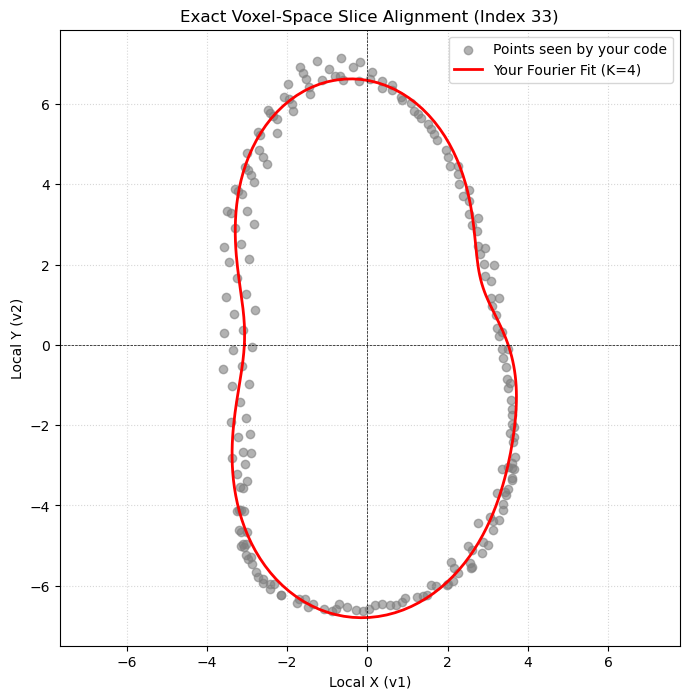

In [15]:
def plot_exact_loop_cross_section(centerline_data, init_mesh, pixel_spacing, K=2):
    """
    Uses your exact extraction logic to pull the middle slice points 
    and plot them against your Fourier fit.
    """
    # 1. Replicate your exact mesh_points scaling from extract_fourier_profiles
    mesh_points = numpy.array(init_mesh.vertices / pixel_spacing[0])
    tree = cKDTree(mesh_points)
    
    # 2. Grab the middle index of the centerline you actually use
    mid_idx = len(centerline_data) // 3
    p = centerline_data[mid_idx]
    
    # 3. Your exact direction calculation
    direction = (
        centerline_data[min(mid_idx+1, len(centerline_data)-1)]
        - centerline_data[max(mid_idx-1, 0)]
    )
    direction /= numpy.linalg.norm(direction)
    
    # 4. Frame and slice selection (identical to your code)
    v1, v2 = get_local_frame(direction)
    idx = tree.query_ball_point(p, r=45)
    local_pts = mesh_points[idx] - p
    
    dist_plane = numpy.dot(local_pts, direction)
    slab = numpy.abs(dist_plane) < 2
    local_pts = local_pts[slab]
    
    if len(local_pts) < 20:
        print(f"Slice {mid_idx} has too few points ({len(local_pts)}) to plot.")
        return
        
    # 5. Projecting to 2D
    x = local_pts @ v1
    y = local_pts @ v2
    
    # 6. Calculate angles and fit
    theta = numpy.arctan2(y, x)
    r = numpy.sqrt(x*x + y*y)
    
    # Fit using your exact function
    coeffs = fit_fourier_contour(theta, r, K=K)
    
    # 7. Evaluate on a clean, wrapped grid to prevent double-line artifacts
    theta_fit = numpy.linspace(-numpy.pi, numpy.pi, 200)
    r_fit = evaluate_fourier_contour(coeffs, theta_fit)
    r_fit = numpy.maximum(r_fit, 0.05)
    
    x_fit = r_fit * numpy.cos(theta_fit)
    y_fit = r_fit * numpy.sin(theta_fit)
    
    # Close the circle loop
    x_fit = numpy.append(x_fit, x_fit[0])
    y_fit = numpy.append(y_fit, y_fit[0])
    
    # 8. Plotting
    plt.figure(figsize=(8, 8))
    plt.scatter(x, y, color='gray', alpha=0.6, label='Points seen by your code')
    plt.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Your Fourier Fit (K={K})')
    
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axis('equal')
    plt.title(f"Exact Voxel-Space Slice Alignment (Index {mid_idx})")
    plt.xlabel("Local X (v1)")
    plt.ylabel("Local Y (v2)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

# --- HOW TO RUN IT IN YOUR LOOP ---
# Replace your current loop's plotting call with this, testing both centerline variants:
plot_exact_loop_cross_section(centerlines[muscle_id], init_mesh, pixel_spacing, K=4)

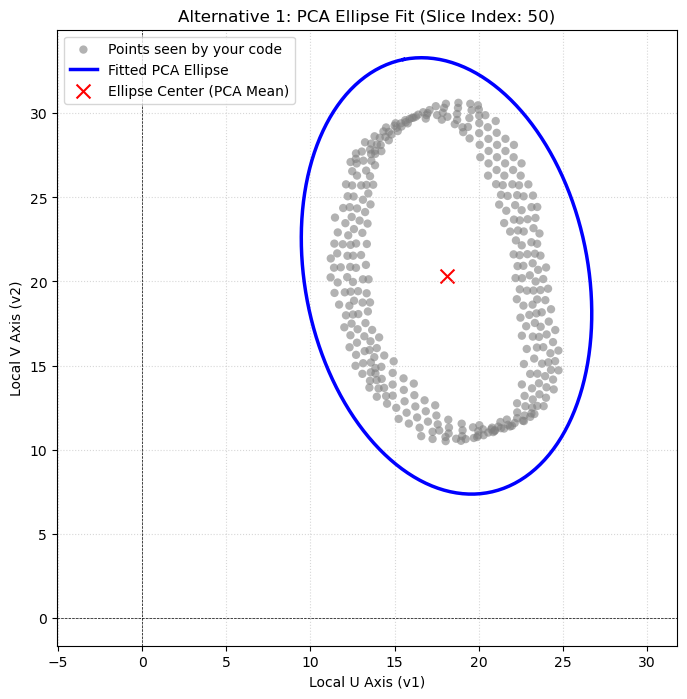

In [16]:
from sklearn.decomposition import PCA

def plot_pca_ellipse_cross_section(centerlines, init_mesh, pixel_spacing):
    """
    Extracts the middle cross-section of the first muscle using your exact logic,
    fits a PCA-based ellipse to the 2D projected point cloud, and plots it.
    """
    # -------------------------------------------------------------------------
    # 1. Isolate the middle slice (Your exact extraction logic)
    # -------------------------------------------------------------------------
    centerline_data = centerlines[0]
    mid_idx = len(centerline_data) // 2
    p = centerline_data[mid_idx]
    
    # Calculate local direction
    direction = (
        centerline_data[min(mid_idx + 1, len(centerline_data) - 1)]
        - centerline_data[max(mid_idx - 1, 0)]
    )
    direction /= numpy.linalg.norm(direction)
    
    # Get local coordinate frames (v1, v2)
    v1, v2 = get_local_frame(direction)
    
    # Slice the mesh point cloud in voxel space
    mesh_points = numpy.array(init_mesh.vertices / pixel_spacing[0])
    tree = cKDTree(mesh_points)
    
    idx = tree.query_ball_point(p, r=45)
    local_pts = mesh_points[idx] - p
    
    dist_plane = numpy.dot(local_pts, direction)
    slab = numpy.abs(dist_plane) < 2
    local_pts = local_pts[slab]
    
    if len(local_pts) < 20:
        print(f"Slice {mid_idx} has too few points ({len(local_pts)}) to fit an ellipse.")
        return
        
    # -------------------------------------------------------------------------
    # 2. Project 3D points to 2D local frame
    # -------------------------------------------------------------------------
    x = local_pts @ v1
    y = local_pts @ v2
    
    # Combine x and y into a 2D data matrix for PCA
    pts_2d = numpy.column_stack((x, y))
    
    # -------------------------------------------------------------------------
    # 3. Fit the PCA Ellipse
    # -------------------------------------------------------------------------
    pca = PCA(n_components=2)
    pca.fit(pts_2d)
    
    # The center of the ellipse is the mean of the points
    center = pca.mean_
    
    # The lengths of the major/minor axes are derived from the variance.
    # Multiplying the standard deviation (sqrt of variance) by 2 covers 
    # roughly 95% of the data envelope. Adjust this scalar if needed!
    lengths = 2.0 * numpy.sqrt(pca.explained_variance_)
    
    # Calculate the tilt angle of the principal component relative to local U (v1)
    angle = numpy.arctan2(pca.components_[0, 1], pca.components_[0, 0])
    
    # -------------------------------------------------------------------------
    # 4. Generate Ellipse Contour Points for Plotting
    # -------------------------------------------------------------------------
    t = numpy.linspace(0, 2 * numpy.pi, 150)
    
    # Parametric equations for a rotated ellipse
    ellipse_x = (center[0] 
                 + lengths[0] * numpy.cos(t) * numpy.cos(angle) 
                 - lengths[1] * numpy.sin(t) * numpy.sin(angle))
                 
    ellipse_y = (center[1] 
                 + lengths[0] * numpy.cos(t) * numpy.sin(angle) 
                 + lengths[1] * numpy.sin(t) * numpy.cos(angle))
    
    # -------------------------------------------------------------------------
    # 5. Plotting
    # -------------------------------------------------------------------------
    plt.figure(figsize=(8, 8))
    
    # Raw point cloud slice
    plt.scatter(x, y, color='gray', alpha=0.6, label='Points seen by your code', edgecolors='none')
    
    # Fitted PCA Ellipse
    plt.plot(ellipse_x, ellipse_y, color='blue', linewidth=2.5, label='Fitted PCA Ellipse')
    
    # Plot the center point
    plt.scatter([center[0]], [center[1]], color='red', marker='x', s=100, label='Ellipse Center (PCA Mean)')
    
    # Formatting
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axis('equal')  # Critical for 1:1 geometric aspect ratio
    plt.title(f"Alternative 1: PCA Ellipse Fit (Slice Index: {mid_idx})")
    plt.xlabel("Local U Axis (v1)")
    plt.ylabel("Local V Axis (v2)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

# --- HOW TO RUN ---
# Pass your active loop variables straight into it:
plot_pca_ellipse_cross_section(centerlines, init_mesh, pixel_spacing)

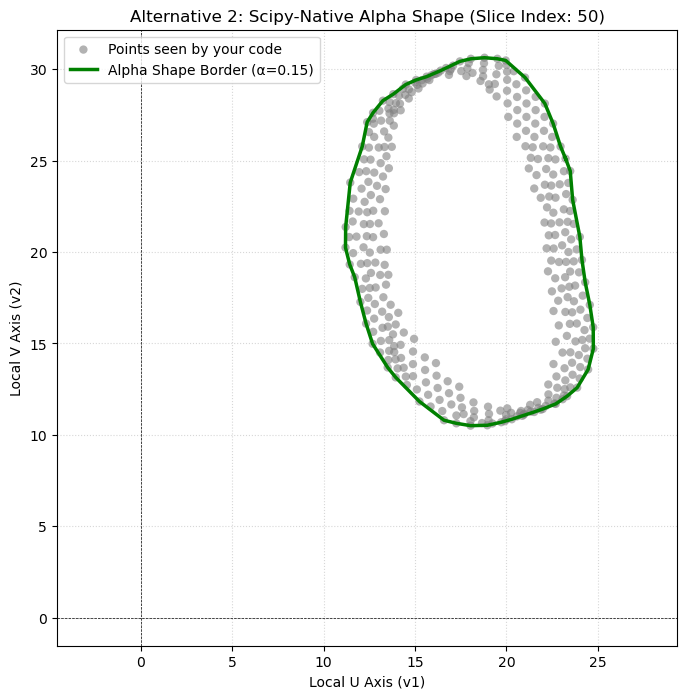

In [17]:
from scipy.spatial import cKDTree, Delaunay

def plot_scipy_alpha_shape(centerlines, init_mesh, pixel_spacing, alpha=0.15):
    """
    Extracts the middle slice points using your logic, computes a concave hull
    (Alpha Shape) using Scipy's Delaunay triangulation, and plots it.
    
    alpha: float
        Controls how tightly the border hugs the data.
        - Higher alpha (e.g., 0.3) snaps aggressively into gaps.
        - Lower alpha (e.g., 0.05) leaves it smooth like a convex hull.
    """
    # -------------------------------------------------------------------------
    # 1. Isolate the middle slice (Your exact extraction logic)
    # -------------------------------------------------------------------------
    centerline_data = centerlines[0]
    mid_idx = len(centerline_data) // 2
    p = centerline_data[mid_idx]
    
    direction = (
        centerline_data[min(mid_idx + 1, len(centerline_data) - 1)]
        - centerline_data[max(mid_idx - 1, 0)]
    )
    direction /= numpy.linalg.norm(direction)
    v1, v2 = get_local_frame(direction)
    
    mesh_points = numpy.array(init_mesh.vertices / pixel_spacing[0])
    tree = cKDTree(mesh_points)
    
    idx = tree.query_ball_point(p, r=45)
    local_pts = mesh_points[idx] - p
    
    dist_plane = numpy.dot(local_pts, direction)
    slab = numpy.abs(dist_plane) < 2
    local_pts = local_pts[slab]
    
    if len(local_pts) < 20:
        print(f"Slice {mid_idx} has too few points to fit.")
        return
        
    # Project 3D points to 2D local frame
    x = local_pts @ v1
    y = local_pts @ v2
    pts_2d = numpy.column_stack((x, y))
    
    # -------------------------------------------------------------------------
    # 2. Compute the Alpha Shape using Delaunay Triangulation
    # -------------------------------------------------------------------------
    tri = Delaunay(pts_2d)
    edges = set()
    
    # Loop through triangles; keep edges whose circumradius is small enough
    for ia, ib, ic in tri.simplices:
        pa = pts_2d[ia]
        pb = pts_2d[ib]
        pc = pts_2d[ic]
        
        # Calculate triangle side lengths
        a = numpy.linalg.norm(pa - pb)
        b = numpy.linalg.norm(pb - pc)
        c = numpy.linalg.norm(pc - pa)
        
        # Triangle area via Heron's formula
        s = (a + b + c) / 2.0
        area = numpy.sqrt(max(s * (s - a) * (s - b) * (s - c), 1e-10))
        
        # Circumradius R = (abc) / (4 * Area)
        circum_r = (a * b * c) / (4.0 * area)
        
        # If the triangle fits within the alpha radius filter, log its outer edges
        if circum_r < (1.0 / alpha):
            for edge in [(ia, ib), (ib, ic), (ic, ia)]:
                # If an edge is shared by multiple kept triangles, it's interior
                # We only want the unique perimeter boundary edges
                sorted_edge = tuple(sorted(edge))
                if sorted_edge in edges:
                    edges.remove(sorted_edge)
                else:
                    edges.add(sorted_edge)

    # -------------------------------------------------------------------------
    # 3. Sort perimeter edges into a single continuous loop path
    # -------------------------------------------------------------------------
    edge_dict = {}
    for i, j in edges:
        edge_dict.setdefault(i, []).append(j)
        edge_dict.setdefault(j, []).append(i)
        
    if not edge_dict:
        print("Alpha value is too high! No geometry generated. Try a smaller alpha.")
        return

    # Trace vertices sequentially to draw a single continuous line string
    start_node = next(iter(edge_dict.keys()))
    path = [start_node]
    curr_node = start_node
    prev_node = None
    
    while True:
        neighbors = edge_dict[curr_node]
        next_node = neighbors[0] if neighbors[0] != prev_node else neighbors[1] if len(neighbors) > 1 else None
        if next_node is None or next_node == start_node:
            path.append(start_node)
            break
        path.append(next_node)
        prev_node = curr_node
        curr_node = next_node
        if len(path) > len(edge_dict): # Prevent infinite safety loop
            path.append(start_node)
            break

    hull_x = pts_2d[path, 0]
    hull_y = pts_2d[path, 1]

    # -------------------------------------------------------------------------
    # 4. Plotting
    # -------------------------------------------------------------------------
    plt.figure(figsize=(8, 8))
    plt.scatter(x, y, color='gray', alpha=0.6, label='Points seen by your code', edgecolors='none')
    plt.plot(hull_x, hull_y, color='green', linewidth=2.5, label=f'Alpha Shape Border (α={alpha})')
    
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axis('equal')
    plt.title(f"Alternative 2: Scipy-Native Alpha Shape (Slice Index: {mid_idx})")
    plt.xlabel("Local U Axis (v1)")
    plt.ylabel("Local V Axis (v2)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

# --- HOW TO RUN ---
plot_scipy_alpha_shape(centerlines, init_mesh, pixel_spacing, alpha=0.15)

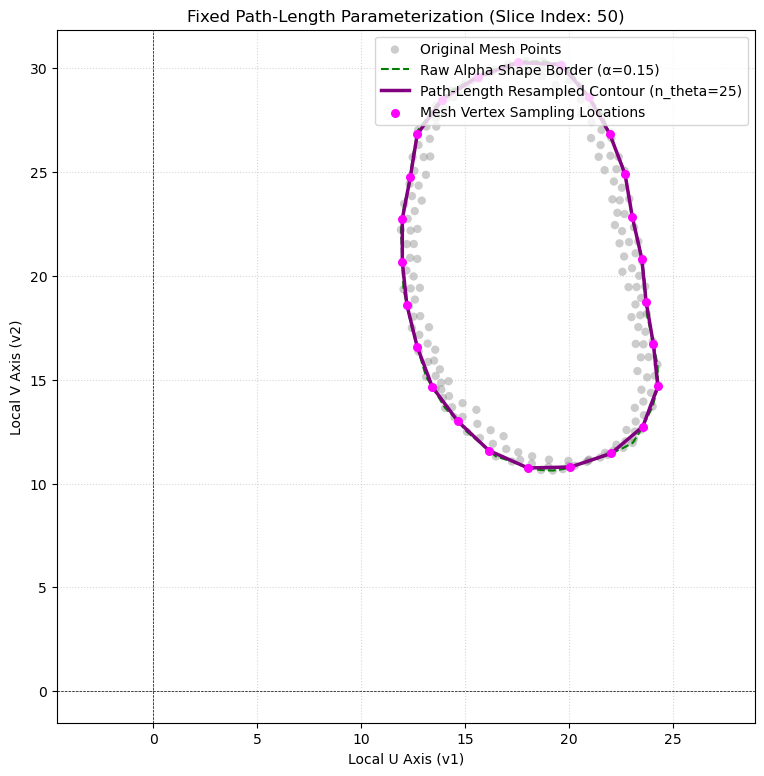

In [18]:
def plot_parametric_path_alpha_contour(centerlines, init_mesh, pixel_spacing, n_theta=64, alpha=0.15):
    """
    Extracts the slice, computes the alpha shape, and resamples it into a 
    uniform parametric array based on cumulative path length to safely handle non-convexities.
    """
    # -------------------------------------------------------------------------
    # 1. Isolate the middle slice (Your exact extraction logic)
    # -------------------------------------------------------------------------
    centerline_data = centerlines[0]
    mid_idx = len(centerline_data) // 2
    p = centerline_data[mid_idx]
    
    direction = (
        centerline_data[min(mid_idx + 1, len(centerline_data) - 1)]
        - centerline_data[max(mid_idx - 1, 0)]
    )
    direction /= numpy.linalg.norm(direction)
    v1, v2 = get_local_frame(direction)
    
    mesh_points = numpy.array(init_mesh.vertices / pixel_spacing[0])
    tree = cKDTree(mesh_points)
    
    idx = tree.query_ball_point(p, r=45)
    local_pts = mesh_points[idx] - p
    
    dist_plane = numpy.dot(local_pts, direction)
    slab = numpy.abs(dist_plane) < 1
    local_pts = local_pts[slab]
    
    if len(local_pts) < 20:
        print(f"Slice {mid_idx} has too few points to process.")
        return
        
    # Project 3D points to 2D local frame
    x = local_pts @ v1
    y = local_pts @ v2
    pts_2d = numpy.column_stack((x, y))
    
    # -------------------------------------------------------------------------
    # 2. Compute the Alpha Shape using Delaunay Triangulation
    # -------------------------------------------------------------------------
    tri = Delaunay(pts_2d)
    edges = set()
    for ia, ib, ic in tri.simplices:
        pa, pb, pc = pts_2d[ia], pts_2d[ib], pts_2d[ic]
        a, b, c = numpy.linalg.norm(pa-pb), numpy.linalg.norm(pb-pc), numpy.linalg.norm(pc-pa)
        s = (a + b + c) / 2.0
        area = numpy.sqrt(max(s * (s - a) * (s - b) * (s - c), 1e-10))
        if (a * b * c) / (4.0 * area) < (1.0 / alpha):
            for edge in [(ia, ib), (ib, ic), (ic, ia)]:
                sorted_edge = tuple(sorted(edge))
                if sorted_edge in edges: edges.remove(sorted_edge)
                else: edges.add(sorted_edge)

    # Trace unique perimeter edges into a sequential node path
    edge_dict = {}
    for ui, uj in edges:
        edge_dict.setdefault(ui, []).append(uj)
        edge_dict.setdefault(uj, []).append(ui)

    if not edge_dict:
        print("Alpha value is too high for this slice!")
        return

    start_node = next(iter(edge_dict.keys()))
    path = [start_node]
    curr_node, prev_node = start_node, None
    while True:
        neighbors = edge_dict[curr_node]
        next_node = neighbors[0] if neighbors[0] != prev_node else neighbors[1] if len(neighbors) > 1 else None
        if next_node is None or next_node == start_node: break
        path.append(next_node)
        prev_node, curr_node = curr_node, next_node
        if len(path) > len(edge_dict): break

    # Append the start node to close the loop physically
    path.append(start_node)
    hull_pts = pts_2d[path]

    # -------------------------------------------------------------------------
    # 3. Parametric Encoding: Resample by Path Length (safely handles folds/crescents)
    # -------------------------------------------------------------------------
    # Compute the distance between each consecutive point along the perimeter
    segment_lengths = numpy.sqrt(numpy.sum(numpy.diff(hull_pts, axis=0)**2, axis=1))
    
    # Generate the cumulative distance array (starts at 0, ends at total perimeter length)
    cumulative_distance = numpy.concatenate(([0], numpy.cumsum(segment_lengths)))
    total_length = cumulative_distance[-1]
    
    # Create an evenly spaced target grid from 0 to the total perimeter length
    # We choose n_theta points. (endpoint=False matches your loop setup)
    target_distances = numpy.linspace(0, total_length, n_theta, endpoint=False)
    
    # Linearly interpolate the X and Y coordinates independently based on distance
    parametric_x = numpy.interp(target_distances, cumulative_distance, hull_pts[:, 0])
    parametric_y = numpy.interp(target_distances, cumulative_distance, hull_pts[:, 1])

    # Close loops for drawing purposes
    parametric_x_closed = numpy.append(parametric_x, parametric_x[0])
    parametric_y_closed = numpy.append(parametric_y, parametric_y[0])

    # -------------------------------------------------------------------------
    # 4. Plotting
    # -------------------------------------------------------------------------
    plt.figure(figsize=(9, 9))
    
    # 1. Original points
    plt.scatter(x, y, color='gray', alpha=0.4, label='Original Mesh Points', edgecolors='none')
    
    # 2. Raw Alpha Shape Boundary
    plt.plot(hull_pts[:, 0], hull_pts[:, 1], color='green', linewidth=1.5, 
             linestyle='--', label=f'Raw Alpha Shape Border (α={alpha})')
    
    # 3. Parametric Path-Resampled Contour
    plt.plot(parametric_x_closed, parametric_y_closed, color='purple', linewidth=2.5, 
             label=f'Path-Length Resampled Contour (n_theta={n_theta})')
    
    # 4. Explicitly mark vertex points
    plt.scatter(parametric_x, parametric_y, color='magenta', s=30, zorder=5, 
                label='Mesh Vertex Sampling Locations')
    
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axis('equal')
    plt.title(f"Fixed Path-Length Parameterization (Slice Index: {mid_idx})")
    plt.xlabel("Local U Axis (v1)")
    plt.ylabel("Local V Axis (v2)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

# --- HOW TO RUN ---
plot_parametric_path_alpha_contour(centerlines, init_mesh, pixel_spacing, n_theta=25, alpha=0.15)

## Voxel-based fit

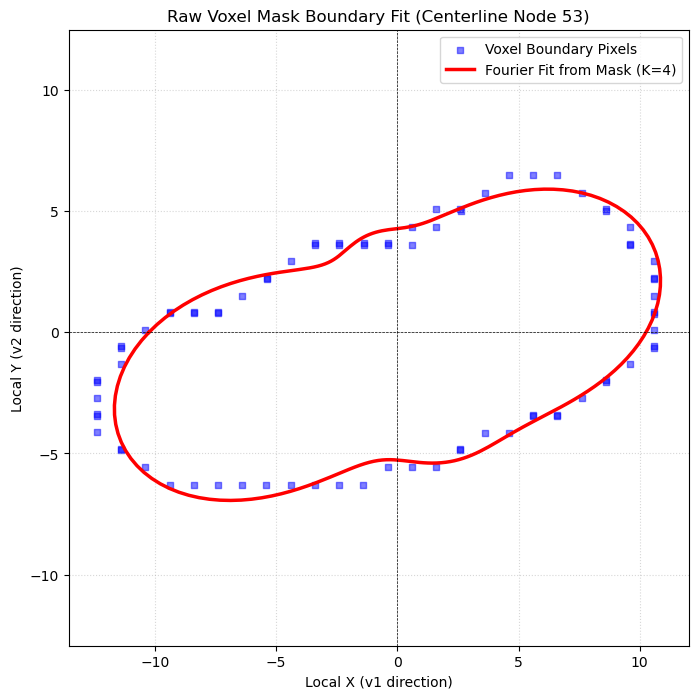

In [ ]:
from scipy.ndimage import binary_dilation

def plot_mask_cross_section(centerline_data, mask, pixel_spacing, K=4):
    """
    Fits and plots a Fourier contour using the voxelized binary mask boundary 
    instead of an STL surface mesh.
    """
    # 1. Extract boundary voxels of the mask to save computational time
    # (A voxel is on the boundary if it is 1, but its neighbors touch 0)
    boundary_mask = mask & ~binary_dilation(mask, structure=numpy.ones((3,3,3))) # Internal boundary
    if not numpy.any(boundary_mask):
        # Fallback if the inversion subtraction is empty due to structuring element
        boundary_mask = mask ^ binary_dilation(mask)
        
    # Get coordinates in (z, y, x) voxel indices
    voxel_coords = numpy.argwhere(boundary_mask) 
    
    # 2. Grab the middle index of the centerline
    mid_idx = len(centerline_data) // 3
    p = centerline_data[mid_idx] # Center point in voxel space
    
    # 3. Calculate local tangent direction
    direction = (
        centerline_data[min(mid_idx+1, len(centerline_data)-1)]
        - centerline_data[max(mid_idx-1, 0)]
    )
    direction /= numpy.linalg.norm(direction)
    
    # 4. Get the 2D local frame transformation vectors
    v1, v2 = get_local_frame(direction)
    
    # 5. Filter for boundary voxels close to our plane (Euclidean distance radius = 45 voxels)
    distances_to_point = numpy.linalg.norm(voxel_coords - p, axis=1)
    close_idx = distances_to_point < 45
    local_voxels = voxel_coords[close_idx] - p
    
    # 6. Slice selection: Grab voxels within a thin slab (thickness +/- 1.0 voxel) around the plane
    dist_plane = numpy.dot(local_voxels, direction)
    slab = numpy.abs(dist_plane) < 1.0
    local_voxels = local_voxels[slab]
    
    if len(local_voxels) < 15:
        print(f"Slice {mid_idx} has too few boundary voxels ({len(local_voxels)}) to fit.")
        return
        
    # 7. Project 3D voxel offsets onto the local 2D plane (v1, v2 coordinates)
    x = local_voxels @ v1
    y = local_voxels @ v2
    
    # 8. Convert to Polar coordinates for Fourier Fitting
    theta = numpy.arctan2(y, x)
    r = numpy.sqrt(x*x + y*y)
    
    # Fit using your exact function
    coeffs = fit_fourier_contour(theta, r, K=K)
    
    # 9. Evaluate fitted contour on a continuous circle array
    theta_fit = numpy.linspace(-numpy.pi, numpy.pi, 200)
    r_fit = evaluate_fourier_contour(coeffs, theta_fit)
    r_fit = numpy.maximum(r_fit, 0.05) # Prevent negative radius artifacts
    
    x_fit = r_fit * numpy.cos(theta_fit)
    y_fit = r_fit * numpy.sin(theta_fit)
    
    # Close the loop visually
    x_fit = numpy.append(x_fit, x_fit[0])
    y_fit = numpy.append(y_fit, y_fit[0])
    
    # 10. Plotting results
    plt.figure(figsize=(8, 8))
    plt.scatter(x, y, color='blue', s=25, alpha=0.5, marker='s', label='Voxel Boundary Pixels')
    plt.plot(x_fit, y_fit, color='red', linewidth=2.5, label=f'Fourier Fit from Mask (K={K})')
    
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axis('equal')
    plt.title(f"Raw Voxel Mask Boundary Fit (Centerline Node {mid_idx})")
    plt.xlabel("Local X (v1 direction)")
    plt.ylabel("Local Y (v2 direction)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()


muscle_id = 0


plot_mask_cross_section(
    centerline_data=extended_centerlines_1[muscle_id], 
    mask=muscles[muscle_id], 
    pixel_spacing=pixel_spacing, 
    K=4
)


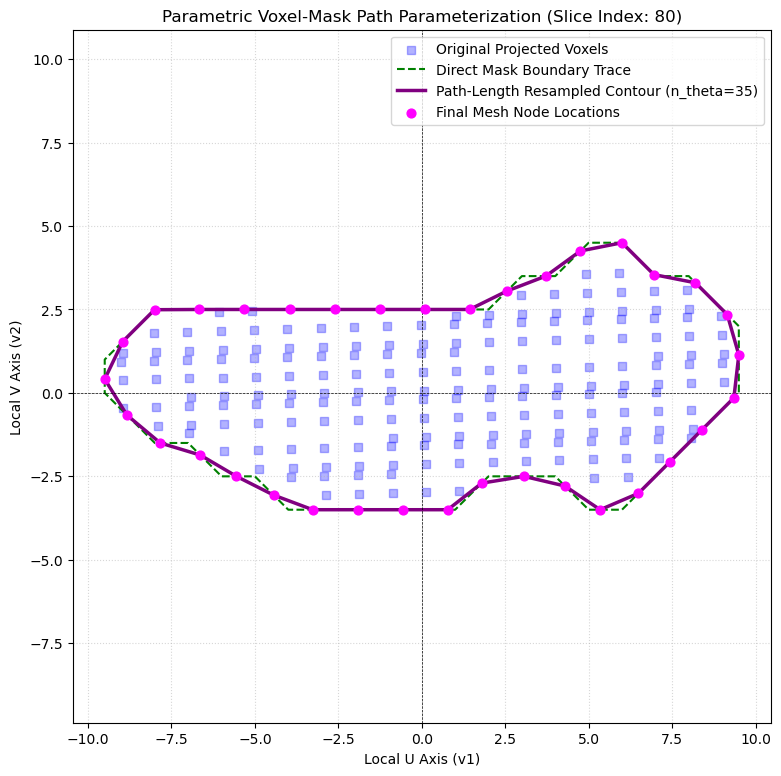

In [ ]:
from skimage import measure  

def plot_parametric_path_mask_contour(centerlines, mask, pixel_spacing, n_theta=64):
    """
    Extracts a 2D cross-section from a 3D binary mask, traces its perimeter 
    using marching squares, and resamples it into a uniform parametric array 
    based on cumulative path length to cleanly handle non-convex shapes.
    """
    # -------------------------------------------------------------------------
    # 1. Isolate the middle slice in voxel space
    # -------------------------------------------------------------------------
    centerline_data = centerlines[0]
    mid_idx = len(centerline_data) // 2
    p = centerline_data[mid_idx]
    
    direction = (
        centerline_data[min(mid_idx + 1, len(centerline_data) - 1)]
        - centerline_data[max(mid_idx - 1, 0)]
    )
    direction /= numpy.linalg.norm(direction)
    v1, v2 = get_local_frame(direction)
    
    # Grab all coordinates where the mask is active
    voxel_coords = numpy.argwhere(mask)
    if len(voxel_coords) == 0:
        print("Mask is empty!")
        return
        
    # Query voxels inside a local neighborhood radius (45 voxels) around the node
    tree = cKDTree(voxel_coords)
    idx = tree.query_ball_point(p, r=45)
    
    if len(idx) < 20:
        print(f"Slice {mid_idx} has too few voxels nearby.")
        return
        
    local_voxels = voxel_coords[idx] - p
    
    # Slice selection: project onto plane normal and take a thin slab (+/- 1.0 voxel)
    dist_plane = numpy.dot(local_voxels, direction)
    slab = numpy.abs(dist_plane) < 1.0
    local_voxels = local_voxels[slab]
    
    if len(local_voxels) < 20:
        print(f"Slice {mid_idx} has too few slice voxels to process.")
        return
        
    # Project 3D voxel offsets onto the local 2D plane coordinates
    x = local_voxels @ v1
    y = local_voxels @ v2
    
    # -------------------------------------------------------------------------
    # 2. Extract Boundary Contour directly from the 2D Point Distribution
    # -------------------------------------------------------------------------
    # To run a robust marching squares contour finder, we map our projected points
    # onto a dense temporary 2D mini-grid canvas.
    padding = 3
    x_min, x_max = int(numpy.floor(numpy.min(x))) - padding, int(numpy.ceil(numpy.max(x))) + padding
    y_min, y_max = int(numpy.floor(numpy.min(y))) - padding, int(numpy.ceil(numpy.max(y))) + padding
    
    grid_w = x_max - x_min
    grid_h = y_max - y_min
    
    canvas = numpy.zeros((grid_h, grid_w), dtype=numpy.uint8)
    
    # Rasterize our slice voxels onto the canvas
    canvas_x = numpy.clip(numpy.round(x - x_min).astype(int), 0, grid_w - 1)
    canvas_y = numpy.clip(numpy.round(y - y_min).astype(int), 0, grid_h - 1)
    canvas[canvas_y, canvas_x] = 1
    
    # Find the outer boundary contours at an iso-value of 0.5
    contours = measure.find_contours(canvas, 0.5)
    if not contours:
        print("Could not isolate a clean mask contour for this slice.")
        return
        
    # Grab the largest continuous contour loop found in the slice
    main_contour = max(contours, key=len)
    
    # Map back from canvas pixel coordinates to our physical local 2D x, y space
    hull_pts = numpy.zeros_like(main_contour)
    hull_pts[:, 0] = main_contour[:, 1] + x_min # Canvas column is X
    hull_pts[:, 1] = main_contour[:, 0] + y_min # Canvas row is Y

    # -------------------------------------------------------------------------
    # 3. Parametric Encoding: Resample by Path Length (handles folds/crescents)
    # -------------------------------------------------------------------------
    # Distance between consecutive points along the contour perimeter
    segment_lengths = numpy.sqrt(numpy.sum(numpy.diff(hull_pts, axis=0)**2, axis=1))
    
    # Generate the cumulative distance array
    cumulative_distance = numpy.concatenate(([0], numpy.cumsum(segment_lengths)))
    total_length = cumulative_distance[-1]
    
    # Create an evenly spaced target grid along the total perimeter length
    target_distances = numpy.linspace(0, total_length, n_theta, endpoint=False)
    
    # Linearly interpolate the X and Y coordinates independently based on distance path
    parametric_x = numpy.interp(target_distances, cumulative_distance, hull_pts[:, 0])
    parametric_y = numpy.interp(target_distances, cumulative_distance, hull_pts[:, 1])

    # Close loops for drawing purposes
    parametric_x_closed = numpy.append(parametric_x, parametric_x[0])
    parametric_y_closed = numpy.append(parametric_y, parametric_y[0])

    # -------------------------------------------------------------------------
    # 4. Plotting
    # -------------------------------------------------------------------------
    plt.figure(figsize=(9, 9))
    
    # 1. Original voxel projections
    plt.scatter(x, y, color='blue', alpha=0.3, s=35, marker='s', label='Original Projected Voxels')
    
    # 2. Raw Marching Squares Boundary Trace
    plt.plot(hull_pts[:, 0], hull_pts[:, 1], color='green', linewidth=1.5, 
             linestyle='--', label='Direct Mask Boundary Trace')
    
    # 3. Parametric Path-Resampled Contour
    plt.plot(parametric_x_closed, parametric_y_closed, color='purple', linewidth=2.5, 
             label=f'Path-Length Resampled Contour (n_theta={n_theta})')
    
    # 4. Explicitly mark vertex points
    plt.scatter(parametric_x, parametric_y, color='magenta', s=40, zorder=5, 
                label='Final Mesh Node Locations')
    
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axis('equal')
    plt.title(f"Parametric Voxel-Mask Path Parameterization (Slice Index: {mid_idx})")
    plt.xlabel("Local U Axis (v1)")
    plt.ylabel("Local V Axis (v2)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()


plot_parametric_path_mask_contour(
    centerlines=extended_centerlines_1, 
    mask=muscles[muscle_id], 
    pixel_spacing=pixel_spacing, 
    n_theta=40
)